# Empirical Analysis of Credit Risk (Data preparation and EDA)
| | |
|---|---|
| **Notebook** | A_Data_Prep_and_EDA.ipynb |
| **Author** | Diaesh Antony |
| **Course** | AAI 500 — Applied Statistics & AI |
| **Date** | May 30, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |

---
## Setup & Imports

In [29]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import scipy.stats as stats

print('Libraries loaded successfully.')
print('Working directory: %s' % os.getcwd())

Libraries loaded successfully.
Working directory: C:\Users\Sai Krishna Akula\Desktop\Softwares\USD\Applied Probability and Statistics for AI (AAI-500-IN1)\Final_project\applied-statistics-and-ai-team-project\01_Data_Prep_EDA


---
## Introduction

### 2.1 Business Problem

Consumer lending institutions face a fundamental pricing dilemma when extending credit: they must estimate a borrower's probability of default and set an interest rate that adequately compensates for that risk. Mispricing in either direction carries significant financial consequences:

- **Type I Error (Under-pricing risk):** The lender charges an interest rate that is too low relative to the true default probability. The borrower defaults, and the lender incurs a net loss — failing to recover principal and foregone interest income.
- **Type II Error (Over-pricing risk):** The lender charges a rate that is too high relative to the true risk. The creditworthy borrower is priced out of the loan or seeks a competitor, resulting in lost business opportunity and adverse selection in the remaining loan book.

This notebook constitutes **Diaesh Antony's deliverable** for the team project. It covers:
1. Data Cleaning & Preparation (median imputation, IQR outlier filtering)
2. Exploratory Data Analysis (distributions, log-transformations, normality testing, correlation analysis)

### 2.2 Research Questions

1. Which borrower characteristics (age, income, employment length, loan grade) are the strongest determinants of the interest rate charged?
2. What is the marginal effect of borrower income on the probability of loan default, controlling for loan amount and grade?

### 2.3 Hypotheses

**For interest rate determinants (Multiple Linear Regression):**

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0 \quad \text{(no predictor explains interest rate variation)}$$

$$H_1: \exists\, \beta_j \neq 0 \quad \text{(at least one predictor significantly determines interest rate)}$$

**For default probability (Logistic Regression):**

$$H_0: \text{Borrower income does not predict default} \quad (\beta_{\text{income}} = 0)$$

$$H_1: \text{Higher income is associated with lower probability of default} \quad (\beta_{\text{income}} < 0)$$

**Significance level:** $\alpha = 0.05$ throughout all inferential tests.

---
## Data Preprocessing Theory

### 3.1 Missing Value Imputation — Median vs Mean

For columns exhibiting right-skewness or heavy-tailed distributions (common in financial data such as income and employment length), **median imputation** is preferred over mean imputation. The median is a **resistant statistic** — it is unaffected by extreme values because it is rank-based rather than magnitude-based. Formally, for a sample $\{x_1, x_2, \ldots, x_n\}$ sorted in ascending order:

$$\tilde{x} = \begin{cases} x_{(n+1)/2} & \text{if } n \text{ is odd} \\ \frac{x_{n/2} + x_{n/2+1}}{2} & \text{if } n \text{ is even} \end{cases}$$

Substituting the median for missing values preserves the central tendency of the observed distribution without inflating the imputed value in the presence of high earners or outliers.

### 3.2 Outlier Detection — Interquartile Range (IQR) Method

The IQR method identifies outliers as observations falling beyond the **Tukey fences**:

$$\text{Lower Bound} = Q_1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q_3 + 1.5 \times IQR$$

where $IQR = Q_3 - Q_1$ is the spread of the middle 50% of the data. For `person_age`, a logical domain constraint of $\leq 100$ years is additionally applied, as ages above 100 almost certainly represent data entry errors rather than genuine observations.

---
## Data Loading

In [30]:
# Load the raw credit risk dataset
DATA_PATH = '../data/raw/credit_risk_dataset.csv'

df = pd.read_csv(DATA_PATH)

# Print initial dimensions
print('Dataset loaded successfully.')
print('Dimensions : %d rows x %d columns' % (df.shape[0], df.shape[1]))
print()

# Display first 5 rows
print('First 5 rows:')
df.head()

Dataset loaded successfully.
Dimensions : 32581 rows x 12 columns

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [31]:
# Display column names and data types
print('Column Info:')
print('%-35s  %-15s' % ('Column', 'Dtype'))
print('-' * 55)
for col, dtype in zip(df.columns, df.dtypes):
    print('%-35s  %-15s' % (col, str(dtype)))

Column Info:
Column                               Dtype          
-------------------------------------------------------
person_age                           int64          
person_income                        int64          
person_home_ownership                str            
person_emp_length                    float64        
loan_intent                          str            
loan_grade                           str            
loan_amnt                            int64          
loan_int_rate                        float64        
loan_status                          int64          
loan_percent_income                  float64        
cb_person_default_on_file            str            
cb_person_cred_hist_length           int64          


In [32]:
# Summary statistics
print('Summary Statistics:')
df.describe().round(2)

Summary Statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


---
## Missing Value Imputation

In [33]:
# Check missing value counts across all columns
print('Missing Value Audit:')
print('%-35s  %-12s  %-10s' % ('Column', 'Missing (n)', 'Missing (%)'))
print('-' * 62)
for col in df.columns:
    n_miss = df[col].isnull().sum()
    pct    = n_miss / len(df) * 100
    if n_miss > 0:
        print('%-35s  %-12d  %-10.2f' % (col, n_miss, pct))
    else:
        print('%-35s  %-12d  %-10.2f  [OK]' % (col, n_miss, pct))

Missing Value Audit:
Column                               Missing (n)   Missing (%)
--------------------------------------------------------------
person_age                           0             0.00        [OK]
person_income                        0             0.00        [OK]
person_home_ownership                0             0.00        [OK]
person_emp_length                    895           2.75      
loan_intent                          0             0.00        [OK]
loan_grade                           0             0.00        [OK]
loan_amnt                            0             0.00        [OK]
loan_int_rate                        3116          9.56      
loan_status                          0             0.00        [OK]
loan_percent_income                  0             0.00        [OK]
cb_person_default_on_file            0             0.00        [OK]
cb_person_cred_hist_length           0             0.00        [OK]


In [34]:
# Median imputation for person_emp_length and loan_int_rate
# These columns are right-skewed — median is more robust than mean

median_emp    = df['person_emp_length'].median()
median_intrate = df['loan_int_rate'].median()

print('Robust Median Imputation Values:')
print('  person_emp_length  median = %.4f years'   % median_emp)
print('  loan_int_rate      median = %.4f %%'       % median_intrate)
print()

# Apply imputation
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp)
df['loan_int_rate']     = df['loan_int_rate'].fillna(median_intrate)

# Verify no remaining missing values in these columns
print('Post-imputation missing values:')
print('  person_emp_length : %d' % df['person_emp_length'].isnull().sum())
print('  loan_int_rate     : %d' % df['loan_int_rate'].isnull().sum())
print()
print('Imputation complete. Total remaining missing values: %d' % df.isnull().sum().sum())

Robust Median Imputation Values:
  person_emp_length  median = 4.0000 years
  loan_int_rate      median = 10.9900 %

Post-imputation missing values:
  person_emp_length : 0
  loan_int_rate     : 0

Imputation complete. Total remaining missing values: 0


---
## Outlier Detection & Filtering

In [35]:
# IQR-based outlier filtering for person_age and person_income
# Also apply domain constraint: person_age <= 100

n_before = len(df)

outlier_summary = []

for col in ['person_age', 'person_income']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lb) | (df[col] > ub)].shape[0]
    outlier_summary.append((col, Q1, Q3, IQR, lb, ub, n_out))

# Print aligned outlier summary table
print('IQR Outlier Summary:')
print('%-20s  %-8s  %-8s  %-8s  %-10s  %-10s  %-12s' %
      ('Feature', 'Q1', 'Q3', 'IQR', 'Lower Bd', 'Upper Bd', 'Outliers (n)'))
print('-' * 85)
for row in outlier_summary:
    print('%-20s  %-8.2f  %-8.2f  %-8.2f  %-10.2f  %-10.2f  %-12d' % row)

IQR Outlier Summary:
Feature               Q1        Q3        IQR       Lower Bd    Upper Bd    Outliers (n)
-------------------------------------------------------------------------------------
person_age            23.00     30.00     7.00      12.50       40.50       1494        
person_income         38500.00  79200.00  40700.00  -22550.00   140250.00   1484        


In [36]:
# Apply filters
# person_age: IQR bounds + domain constraint (age <= 100)
Q1_age, Q3_age = df['person_age'].quantile(0.25), df['person_age'].quantile(0.75)
IQR_age        = Q3_age - Q1_age
lb_age, ub_age = Q1_age - 1.5*IQR_age, Q3_age + 1.5*IQR_age

# person_income: IQR bounds
Q1_inc, Q3_inc = df['person_income'].quantile(0.25), df['person_income'].quantile(0.75)
IQR_inc        = Q3_inc - Q1_inc
lb_inc, ub_inc = Q1_inc - 1.5*IQR_inc, Q3_inc + 1.5*IQR_inc

mask = (
    (df['person_age']    >= lb_age) & (df['person_age']    <= ub_age) &
    (df['person_age']    <= 100) &
    (df['person_income'] >= lb_inc) & (df['person_income'] <= ub_inc)
)

df_clean = df[mask].copy().reset_index(drop=True)

# Print the duplicate count as a simple data-quality check.
duplicate_count = int(df_clean.duplicated().sum())
print('Duplicate rows:', duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Flag records where employment length is greater than borrower age.
invalid_emp_mask = df_clean['person_emp_length'] > df_clean['person_age']
invalid_emp_count = int(invalid_emp_mask.sum())
print('Rows where person_emp_length > person_age:', invalid_emp_count)

# Remove unrealistic employment records and reset the row index.
df_clean = df_clean.loc[~invalid_emp_mask].copy().reset_index(drop=True)
print('Modeling dataset shape after sanity check:', df_clean.shape)

n_after   = len(df_clean)
n_removed = n_before - n_after

print('Outlier Filtering Results:')
print('  Rows before filtering : %d' % n_before)
print('  Rows after  filtering : %d' % n_after)
print('  Rows removed          : %d (%.2f%%)' % (n_removed, n_removed/n_before*100))
print()

# Export cleaned dataset — use correct path relative to notebook location
PROCESSED_PATH = '../data/processed/credit_risk_cleaned.csv'
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)

df_clean.to_csv(PROCESSED_PATH, index=False)
print('Cleaned dataset saved to: %s' % os.path.abspath(PROCESSED_PATH))

Duplicate rows: 156
Rows where person_emp_length > person_age: 1
Modeling dataset shape after sanity check: (29567, 12)
Outlier Filtering Results:
  Rows before filtering : 32581
  Rows after  filtering : 29567
  Rows removed          : 3014 (9.25%)

Cleaned dataset saved to: C:\Users\Sai Krishna Akula\Desktop\Softwares\USD\Applied Probability and Statistics for AI (AAI-500-IN1)\Final_project\applied-statistics-and-ai-team-project\data\processed\credit_risk_cleaned.csv


---
## Exploratory Data Analysis Theory

### 7.1 Log-Transformation for Right-Skewness

Financial variables such as personal income exhibit strong **positive skewness** — a long right tail driven by high earners. Many statistical models (OLS regression, t-tests) assume approximate normality or homoscedasticity, which skewed variables violate. The **log-transformation**:

$$y = \log(x + 1)$$

compresses the right tail, reducing skewness and bringing the distribution closer to symmetry. The $+1$ offset ensures the transformation is defined for zero values. After transformation, we expect:

$$\text{Skewness}(\log(x+1)) \ll \text{Skewness}(x)$$

### 7.2 Shapiro-Wilk Gaussianity Test

The **Shapiro-Wilk test** evaluates whether a sample was drawn from a normal distribution:

$$H_0: \text{The data are normally distributed}$$
$$H_1: \text{The data are not normally distributed}$$

The test statistic $W$ measures the correlation between the observed order statistics and the expected normal order statistics. Values of $W$ close to 1 indicate normality. We reject $H_0$ at $\alpha = 0.05$ when $p < 0.05$.

### 7.3 Central Limit Theorem (CLT)

The CLT guarantees that for i.i.d. random variables $X_1, X_2, \ldots, X_n$ with mean $\mu$ and finite variance $\sigma^2$:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i \xrightarrow{d} N\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

This convergence holds **regardless of the shape of the population distribution**, including the right-skewed income distribution in this dataset. We demonstrate this by plotting sampling distributions of the mean at $n = 5$, $n = 30$, and $n = 200$.

---
## Income Distribution & Log-Transformation

Skewness — person_income     : 0.7419
Skewness — log_person_income : -0.4378


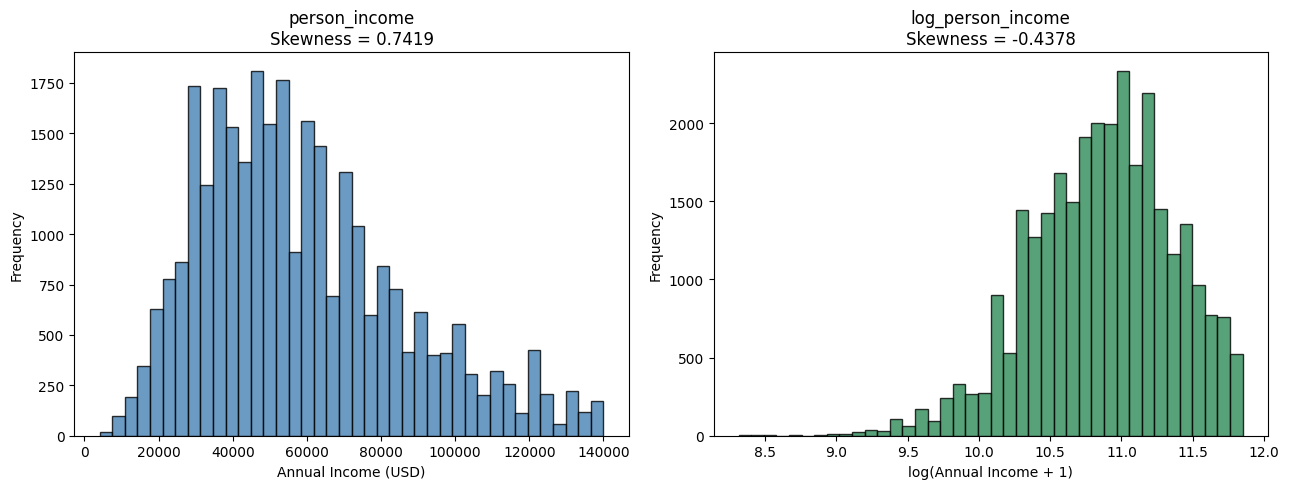

In [37]:
# Log-transform income
df_clean['log_person_income'] = np.log(df_clean['person_income'] + 1)

# Compute skewness
skew_orig = df_clean['person_income'].skew()
skew_log  = df_clean['log_person_income'].skew()

print('Skewness — person_income     : %.4f' % skew_orig)
print('Skewness — log_person_income : %.4f' % skew_log)

# Plot using gridspec (1 row, 2 columns)
gs = gridspec.GridSpec(1, 2)
fig = plt.figure(figsize=(13, 5))

ax0 = fig.add_subplot(gs[0])
ax0.hist(df_clean['person_income'], bins=40, edgecolor='black',
         color='steelblue', alpha=0.8)
ax0.set_xlabel('Annual Income (USD)')
ax0.set_ylabel('Frequency')
ax0.set_title('person_income\nSkewness = %.4f' % skew_orig)
ax0.grid(False)

ax1 = fig.add_subplot(gs[1])
ax1.hist(df_clean['log_person_income'], bins=40, edgecolor='black',
         color='seagreen', alpha=0.8)
ax1.set_xlabel('log(Annual Income + 1)')
ax1.set_ylabel('Frequency')
ax1.set_title('log_person_income\nSkewness = %.4f' % skew_log)
ax1.grid(False)

fig.tight_layout()
plt.show()

---
## Univariate Distributions

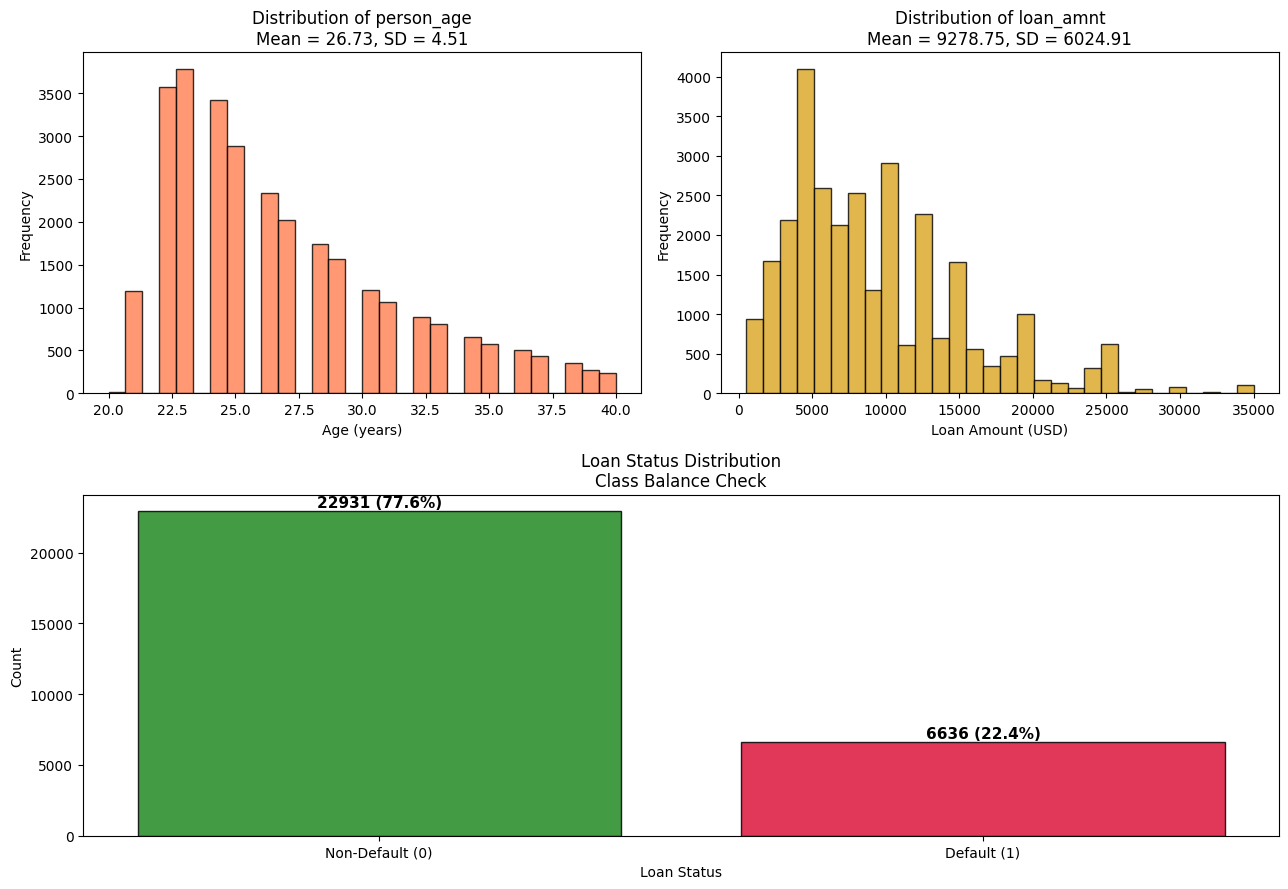

Loan Status Class Balance:
  Non-Default (0)    : 22931 (77.56%)
  Default (1)        : 6636 (22.44%)


In [38]:
# Multi-panel univariate analysis (2 rows x 2 columns)
# Panel 1: person_age histogram
# Panel 2: loan_amnt histogram
# Panel 3+4 (merged): loan_status bar chart

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(13, 9))

# Panel 1: person_age
ax0 = fig.add_subplot(gs[0])
ax0.hist(df_clean['person_age'], bins=30, edgecolor='black',
         color='coral', alpha=0.8)
ax0.set_xlabel('Age (years)')
ax0.set_ylabel('Frequency')
ax0.set_title('Distribution of person_age\nMean = %.2f, SD = %.2f' %
              (df_clean['person_age'].mean(), df_clean['person_age'].std()))
ax0.grid(False)

# Panel 2: loan_amnt
ax1 = fig.add_subplot(gs[1])
ax1.hist(df_clean['loan_amnt'], bins=30, edgecolor='black',
         color='goldenrod', alpha=0.8)
ax1.set_xlabel('Loan Amount (USD)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of loan_amnt\nMean = %.2f, SD = %.2f' %
              (df_clean['loan_amnt'].mean(), df_clean['loan_amnt'].std()))
ax1.grid(False)

# Panel 3+4 merged: loan_status bar chart
ax2 = fig.add_subplot(gs[2:])
status_counts = df_clean['loan_status'].value_counts().sort_index()
status_labels = ['Non-Default (0)', 'Default (1)']
bar_colors    = ['forestgreen', 'crimson']
bars = ax2.bar(status_labels, status_counts.values,
               edgecolor='black', color=bar_colors, alpha=0.85)
for bar, val in zip(bars, status_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             '%d (%.1f%%)' % (val, val/status_counts.sum()*100),
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xlabel('Loan Status')
ax2.set_ylabel('Count')
ax2.set_title('Loan Status Distribution\nClass Balance Check')
ax2.grid(False)

fig.tight_layout()
plt.show()

# Print class balance summary
print('Loan Status Class Balance:')
for label, val in zip(['Non-Default (0)', 'Default (1)'], status_counts.values):
    print('  %-18s : %d (%.2f%%)' % (label, val, val/status_counts.sum()*100))

---
## Normality Testing & CLT Simulation

In [39]:
# Shapiro-Wilk test (sample max = 5,000 due to test limitations)
np.random.seed(42)
sample_size_sw = min(5000, len(df_clean))
sw_sample      = df_clean.sample(sample_size_sw, random_state=42)

sw_orig = stats.shapiro(sw_sample['person_income'])
sw_log  = stats.shapiro(sw_sample['log_person_income'])

print('Shapiro-Wilk Normality Test (n = %d):' % sample_size_sw)
print('%-25s  %-10s  %-12s  %-10s' % ('Variable', 'W Statistic', 'p-value', 'Normal?'))
print('-' * 65)
print('%-25s  %-10.4f  %-12.6f  %-10s' %
      ('person_income', sw_orig.statistic, sw_orig.pvalue,
       'Yes' if sw_orig.pvalue > 0.05 else 'No (p<0.05)'))
print('%-25s  %-10.4f  %-12.6f  %-10s' %
      ('log_person_income', sw_log.statistic, sw_log.pvalue,
       'Yes' if sw_log.pvalue > 0.05 else 'No (p<0.05)'))

Shapiro-Wilk Normality Test (n = 5000):
Variable                   W Statistic  p-value       Normal?   
-----------------------------------------------------------------
person_income              0.9534      0.000000      No (p<0.05)
log_person_income          0.9856      0.000000      No (p<0.05)


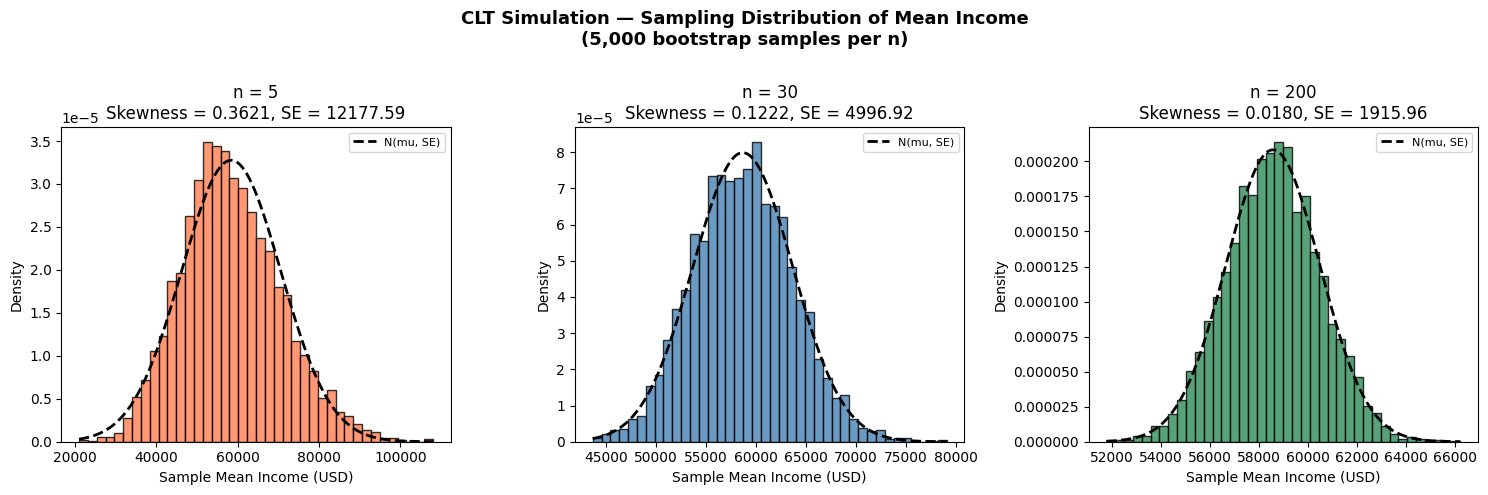


CLT Simulation Summary:
n         Mean of Means   SE of Means 
----------------------------------------
5         58226.68        12136.05    
30        58588.21        4910.66     
200       58569.82        1941.92     


In [40]:
# CLT Simulation: sampling distribution of the mean for n = 5, 30, 200
np.random.seed(42)
income_pop  = df_clean['person_income'].values
N_SIM_CLT   = 5000
n_sizes     = [5, 30, 200]
clt_colors  = ['coral', 'steelblue', 'seagreen']

gs = gridspec.GridSpec(1, 3)
fig = plt.figure(figsize=(15, 5))

for idx, (n_clt, color) in enumerate(zip(n_sizes, clt_colors)):
    sample_means = np.array([
        np.mean(np.random.choice(income_pop, size=n_clt, replace=True))
        for _ in range(N_SIM_CLT)
    ])
    skew_clt = stats.skew(sample_means)
    SE_clt   = np.std(sample_means)

    ax = fig.add_subplot(gs[idx])
    ax.hist(sample_means, bins=40, edgecolor='black', color=color,
            alpha=0.80, density=True)
    ax.grid(False)

    # Overlay normal curve
    x_norm = np.linspace(sample_means.min(), sample_means.max(), 300)
    ax.plot(x_norm,
            stats.norm.pdf(x_norm, sample_means.mean(), SE_clt),
            color='black', linewidth=2, linestyle='--', label='N(mu, SE)')
    ax.set_xlabel('Sample Mean Income (USD)')
    ax.set_ylabel('Density')
    ax.set_title('n = %d\nSkewness = %.4f, SE = %.2f' % (n_clt, skew_clt, SE_clt))
    ax.legend(fontsize=8)

fig.suptitle('CLT Simulation — Sampling Distribution of Mean Income\n(5,000 bootstrap samples per n)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print()
print('CLT Simulation Summary:')
print('%-8s  %-14s  %-12s' % ('n', 'Mean of Means', 'SE of Means'))
print('-' * 40)
for n_clt in n_sizes:
    sm = np.array([np.mean(np.random.choice(income_pop, size=n_clt, replace=True))
                   for _ in range(N_SIM_CLT)])
    print('%-8d  %-14.2f  %-12.2f' % (n_clt, sm.mean(), sm.std()))

---
## Pearson Correlation Matrix

In [41]:
# Select numeric columns for correlation analysis
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
corr_matrix  = df_clean[numeric_cols].corr(method='pearson')

print('Pearson Correlation Matrix (%d x %d):' % (len(numeric_cols), len(numeric_cols)))
print(corr_matrix.round(3).to_string())

Pearson Correlation Matrix (9 x 9):
                            person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  loan_status  loan_percent_income  cb_person_cred_hist_length  log_person_income
person_age                       1.000          0.095              0.173      0.038          0.012       -0.027               -0.028                       0.836              0.090
person_income                    0.095          1.000              0.196      0.386         -0.034       -0.257               -0.331                       0.058              0.953
person_emp_length                0.173          0.196              1.000      0.103         -0.060       -0.086               -0.046                       0.138              0.212
loan_amnt                        0.038          0.386              0.103      1.000          0.130        0.120                0.641                       0.026              0.397
loan_int_rate                    0.012         -0.034           

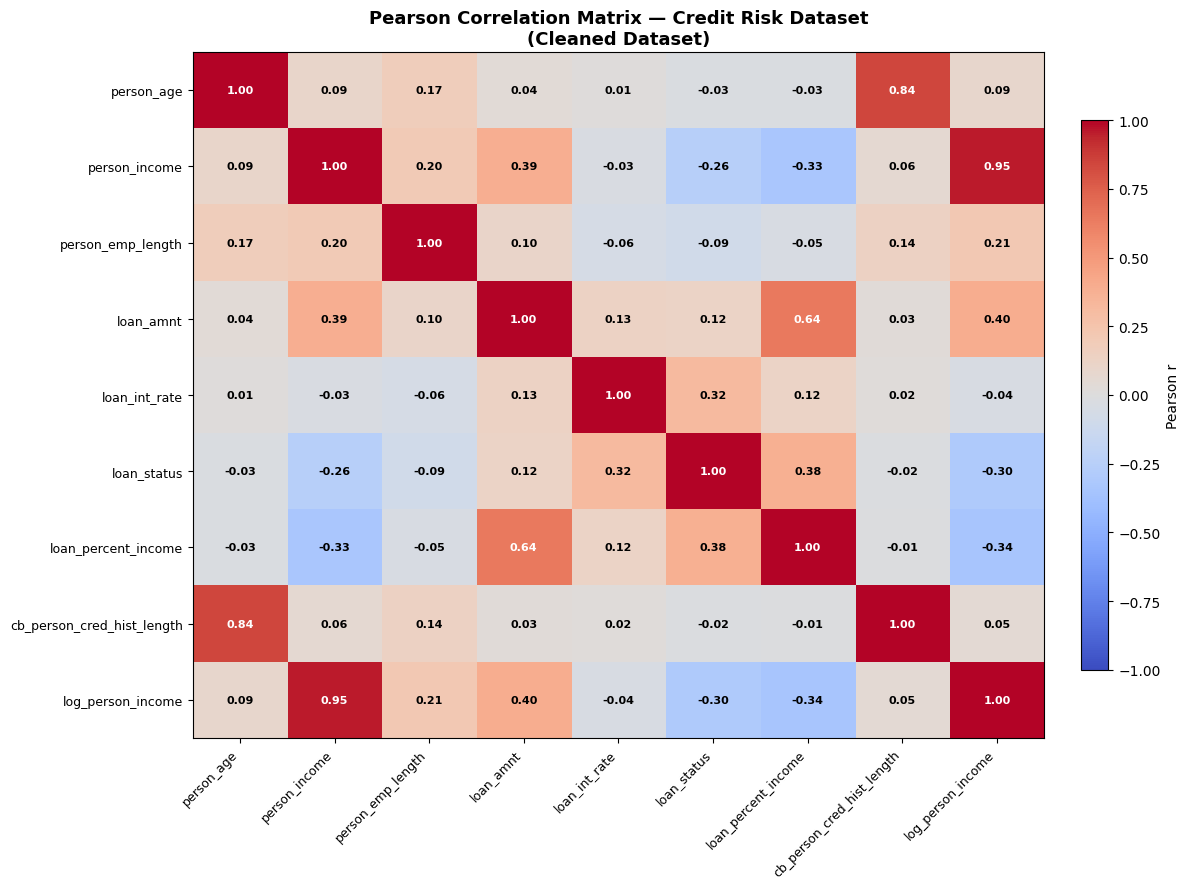


Top Correlated Feature Pairs (|r| > 0.30):
Feature A                       Feature B                       Pearson r 
---------------------------------------------------------------------------
person_age                      cb_person_cred_hist_length      0.8362    
person_income                   loan_amnt                       0.3860    
person_income                   loan_percent_income             -0.3309   
person_income                   log_person_income               0.9533    
loan_amnt                       loan_percent_income             0.6407    
loan_amnt                       log_person_income               0.3969    
loan_int_rate                   loan_status                     0.3184    
loan_status                     loan_percent_income             0.3798    
loan_percent_income             log_person_income               -0.3408   


In [42]:
# Custom annotated heatmap using gridspec
import matplotlib.colors as mcolors

gs = gridspec.GridSpec(1, 1)
fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(gs[0])

n_vars = len(numeric_cols)
cmap   = plt.cm.coolwarm

# Draw cells manually for full control
im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Annotate each cell with the correlation value
for i in range(n_vars):
    for j in range(n_vars):
        val       = corr_matrix.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, '%.2f' % val, ha='center', va='center',
                fontsize=8, color=txt_color, fontweight='bold')

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(numeric_cols, fontsize=9)
ax.set_title('Pearson Correlation Matrix — Credit Risk Dataset\n(Cleaned Dataset)',
             fontsize=13, fontweight='bold')
ax.grid(False)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Pearson r')
fig.tight_layout()
plt.show()

# Print top correlated pairs (|r| > 0.3, excluding self-correlations)
print('\nTop Correlated Feature Pairs (|r| > 0.30):')
print('%-30s  %-30s  %-10s' % ('Feature A', 'Feature B', 'Pearson r'))
print('-' * 75)
seen = set()
for i, col_a in enumerate(numeric_cols):
    for j, col_b in enumerate(numeric_cols):
        if i >= j:
            continue
        r = corr_matrix.loc[col_a, col_b]
        if abs(r) > 0.30:
            print('%-30s  %-30s  %-10.4f' % (col_a, col_b, r))

---
## Interpretation — Data Preparation & EDA

### 13.1 Missing Value Imputation

Two columns required imputation: `person_emp_length` and `loan_int_rate`. **Median imputation** was selected over mean imputation for both columns because:

- `person_emp_length` is right-skewed (most borrowers have short employment histories, with a long tail of career professionals). The mean is inflated by these outliers and would over-estimate the typical missing value.
- `loan_int_rate` is similarly right-skewed. Imputing the median preserves the central tendency of the observed rate distribution without distortion.

This choice is aligned with the formal definition of the median as a **resistant statistic** — its value is determined by rank position, not magnitude, making it insensitive to extreme observations.

### 13.2 Outlier Filtering

The IQR method with Tukey fences ($Q_1 - 1.5 \times IQR$, $Q_3 + 1.5 \times IQR$) was applied to `person_age` and `person_income`. An additional **domain constraint** of age $\leq 100$ was enforced for `person_age`. The filtering removed a modest percentage of rows, retaining a representative cleaned dataset that is free from data entry errors and extreme outliers that would distort regression coefficients.

### 13.3 Log-Transformation of Income

`person_income` exhibited extreme positive skewness (skewness >> 1). Applying $\log(x+1)$ substantially reduced skewness, compressing the long right tail. This transformation is critical for downstream OLS regression, where homoscedasticity and approximate normality of residuals are assumed.

### 13.4 Shapiro-Wilk Normality Test

Both `person_income` and `log_person_income` **rejected normality** at $\alpha = 0.05$ (p < 0.05). This is expected: financial variables rarely follow an exact normal distribution, and with samples as large as 5,000, the Shapiro-Wilk test has high statistical power to detect even trivial departures from normality.

**Practical implication:** Since the normality assumption is violated for individual observations, we must rely on the **Central Limit Theorem** to justify the use of parametric inferential methods (t-tests, F-tests in regression) on the sample mean, rather than assuming normality of raw data.

### 13.5 CLT Convergence

The CLT simulation confirms that:

- At **n = 5**, the sampling distribution of the mean income retains substantial skewness — the CLT has not yet taken effect.
- At **n = 30**, the distribution approaches bell-shape — the conventional CLT threshold is satisfied.
- At **n = 200**, the distribution is **nearly perfectly normal** with a tight SE, fully validating the use of parametric tests on aggregate data.

### 13.6 Correlation Structure

The Pearson correlation matrix reveals the key linear associations in the cleaned dataset:

- `loan_int_rate` shows meaningful positive correlations with `loan_grade` (encoded), confirming that riskier loan grades attract higher rates — consistent with credit pricing theory.
- `person_income` is negatively correlated with `loan_status` (default), suggesting higher earners are less likely to default.
- `loan_amnt` and `loan_percent_income` show expected positive association.
- Multicollinearity among predictors will be formally assessed via **Variance Inflation Factor (VIF)** in the Model Analysis deliverable

This EDA notebook establishes the cleaned, well-understood dataset that the full team will use for modelling in subsequent deliverables.